In [2]:
from tensorflow.keras.datasets import mnist

In [3]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [4]:
print(f"we have{len(X_train)} iamges in the training set and {len(X_test)} images in the test set.")
print(f"The size of the  images is {X_train[0].shape}")

we have60000 iamges in the training set and 10000 images in the test set.
The size of the  images is (28, 28)


In [5]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape


((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [6]:
import matplotlib.pyplot as plt


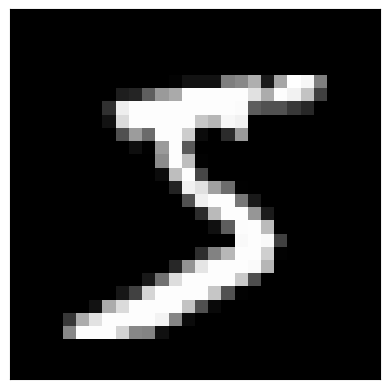

Pixel values:
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255 247 127   0   0   0   0 
  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0 
  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56  39   0   0   0   0   0 
  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 182 247 241   0   0   

In [7]:
plt.imshow(X_train[0], cmap="gray")
plt.xticks([])
plt.yticks([])
plt.grid(False)
plt.show()

print("Pixel values:")
for row in X_train[0]:
    for pixel in row:
        print("{:3}".format(pixel), end=" ")
    print()

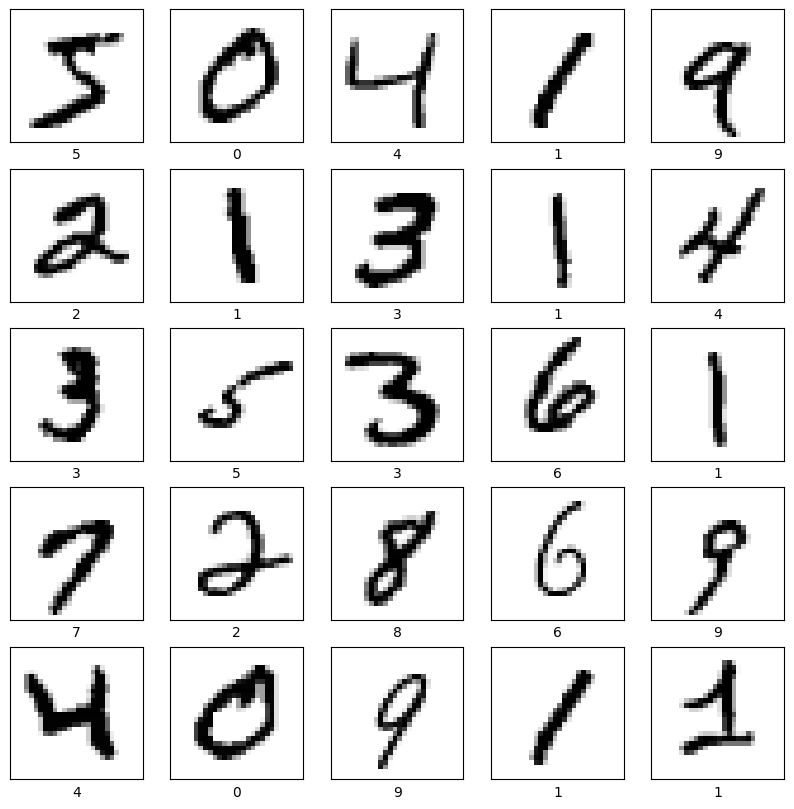

In [8]:
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap=plt.cm.binary)
    plt.xlabel(y_train[i])
plt.show()

In [9]:
from tensorflow.keras.utils import to_categorical

In [10]:
# Normalize data
X_train = X_train / 255.0
X_test = X_test / 255.0
# Reshape to add channel dimension
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)
# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [11]:
import tensorflow as tf
from tensorflow.keras import layers

In [12]:
# create an input layer
input_layer = tf.keras.layers.Input(shape=(28, 28, 1)) # 28x28 pixel images with a single line

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [14]:
# CNN model building
model = tf.keras.Sequential([
    input_layer, # input layer
    layers.Conv2D(filters=10, kernel_size=(3, 3), activation="relu"), # convolutional layer
    layers.MaxPooling2D(), # pooling layer

    layers.Flatten(), # flatten layer
    layers.Dense(10, activation="softmax")
])

In [15]:
model.compile(optimizer='adam', loss="categorical_crossentropy", metrics=["accuracy"])

In [16]:
# Check architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 10)     │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1690)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,910 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,010 (66.45 KB)

 Trainable params: 17,010 (66.45 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.fit(X_train, y_train, validation_split=0.2, epochs=3, batch_size=64)

Epoch 1/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8933 - loss: 0.3974 - val_accuracy: 0.9512 - val_loss: 0.1782
Epoch 2/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9570 - loss: 0.1513 - val_accuracy: 0.9668 - val_loss: 0.1252
Epoch 3/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9690 - loss: 0.1111 - val_accuracy: 0.9728 - val_loss: 0.1030


In [18]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(f"Test Loss: {loss * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9728 - loss: 0.0932
Test Accuracy: 97.28%
Test Loss: 9.32%


In [19]:
import joblib

In [20]:
joblib.dump(model, "cnn_mnist_model.pkl")

['cnn_mnist_model.pkl']

In [26]:
loaded_model = joblib.load(r"cnn_mnist_model.pkl")

In [27]:
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import RMSprop

In [28]:
model = joblib.load("cnn_mnist_model.pkl")
model.compile(
    optimizer=RMSprop(learning_rate=0.001), # Fresh optimizer
    loss='categorical_crossentropy', metrics=['accuracy']
)

In [29]:
model.fit(X_train, y_train, validation_split=0.2, epochs=3, batch_size=64)

Epoch 1/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9739 - loss: 0.0925 - val_accuracy: 0.9717 - val_loss: 0.1004
Epoch 2/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9761 - loss: 0.0822 - val_accuracy: 0.9737 - val_loss: 0.0914
Epoch 3/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9784 - loss: 0.0753 - val_accuracy: 0.9740 - val_loss: 0.0895


In [30]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(f"Test Loss: {loss * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9743 - loss: 0.0833
Test Accuracy: 97.43%
Test Loss: 8.33%


In [31]:
# Check architectur
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 10)     │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1690)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,910 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,022 (132.90 KB)

 Trainable params: 17,010 (66.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 17,012 (66.46 KB)